<a href="https://colab.research.google.com/github/Kavin-Prakash-T/ds-hackathon/blob/main/DS_Hack_Q2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings("ignore")

In [41]:
df = pd.read_csv("ott_show_dataset.csv")

df.head(10)

,Show_ID,Genre,Language,Runtime,Release_Year,Budget,Rating,Viewership
0,SHOW0001,Comedy,Hindi,61,2022,93.84,7.3,10.99
1,SHOW0002,Documentary,English,40,2024,88.50,8.3,9.00
2,SHOW0003,Crime,Kannada,56,2022,32.83,8.6,7.21
3,SHOW0004,Thriller,English,46,2019,72.57,7.9,14.92
4,SHOW0005,Drama,Hindi,48,2019,105.45,7.3,11.33
5,SHOW0006,Drama,Telugu,39,2019,57.53,7.6,9.27
6,SHOW0007,Action,Hindi,44,2023,116.32,7.6,19.87
7,SHOW0008,Sci-Fi,Telugu,25,2020,59.74,6.9,9.39
8,SHOW0009,Romance,English,55,2021,25.71,8.1,8.80
9,SHOW0010,Romance,Hindi,21,2025,52.84,8.0,7.97


In [42]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 2000
Number of columns: 8


In [43]:
print(df.columns.tolist())

['Show_ID', 'Genre', 'Language', 'Runtime', 'Release_Year', 'Budget', 'Rating', 'Viewership']


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Show_ID       2000 non-null   object 
 1   Genre         2000 non-null   object 
 2   Language      2000 non-null   object 
 3   Runtime       2000 non-null   int64  
 4   Release_Year  2000 non-null   int64  
 5   Budget        2000 non-null   float64
 6   Rating        2000 non-null   float64
 7   Viewership    2000 non-null   float64
dtypes: float64(3), int64(2), object(3)
memory usage: 125.1+ KB


In [45]:
df.isnull().sum()

,0
Show_ID,0
Genre,0
Language,0
Runtime,0
Release_Year,0
Budget,0
Rating,0
Viewership,0


In [46]:
print("Duplicate Show IDs:", df["Show_ID"].duplicated().sum())

Duplicate Show IDs: 0


In [47]:
print("Invalid Runtime:",
      (df["Runtime"] <= 0).sum())

print("Invalid Budget:",
      (df["Budget"] <= 0).sum())

print("Invalid Rating:",
      ((df["Rating"] < 0) | (df["Rating"] > 10)).sum())

print("Invalid Viewership:",
      (df["Viewership"] < 0).sum())

Invalid Runtime: 0
Invalid Budget: 0
Invalid Rating: 0
Invalid Viewership: 0


In [48]:
df.describe()

,Runtime,Release_Year,Budget,Rating,Viewership
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,44.462500,2021.432000,63.673920,7.597500,11.023960
std,14.193778,2.276393,31.509778,0.934131,3.698118
min,20.000000,2018.000000,10.030000,4.500000,0.500000
25%,33.000000,2019.000000,36.715000,7.000000,8.260000
50%,44.000000,2021.000000,63.050000,7.600000,10.870000
75%,57.000000,2023.000000,90.267500,8.200000,13.522500
max,69.000000,2025.000000,119.910000,9.800000,26.010000


In [49]:
threshold = df["Viewership"].median()

df["Success"] = np.where(
    df["Viewership"] >= threshold,
    1,
    0
)

df["Success_Label"] = np.where(
    df["Success"] == 1,
    "Successful",
    "Less Successful"
)

print("Success threshold:",
      round(threshold, 2))

Success threshold: 10.87


In [50]:
print(
    df["Success_Label"].value_counts()
)

Success_Label
Successful         1001
Less Successful     999
Name: count, dtype: int64


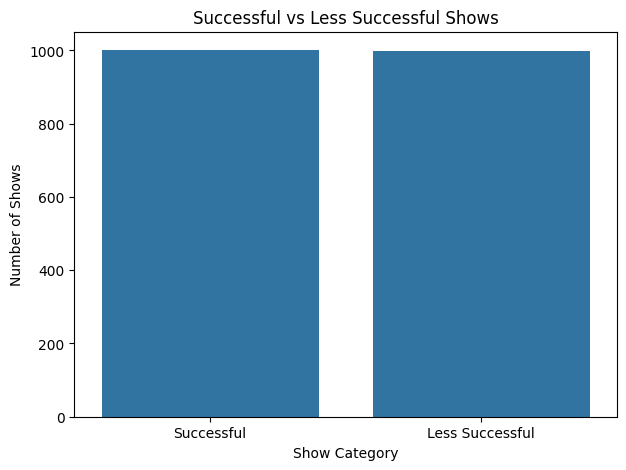

In [51]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Success_Label"
)

plt.title("Successful vs Less Successful Shows")
plt.xlabel("Show Category")
plt.ylabel("Number of Shows")

plt.show()

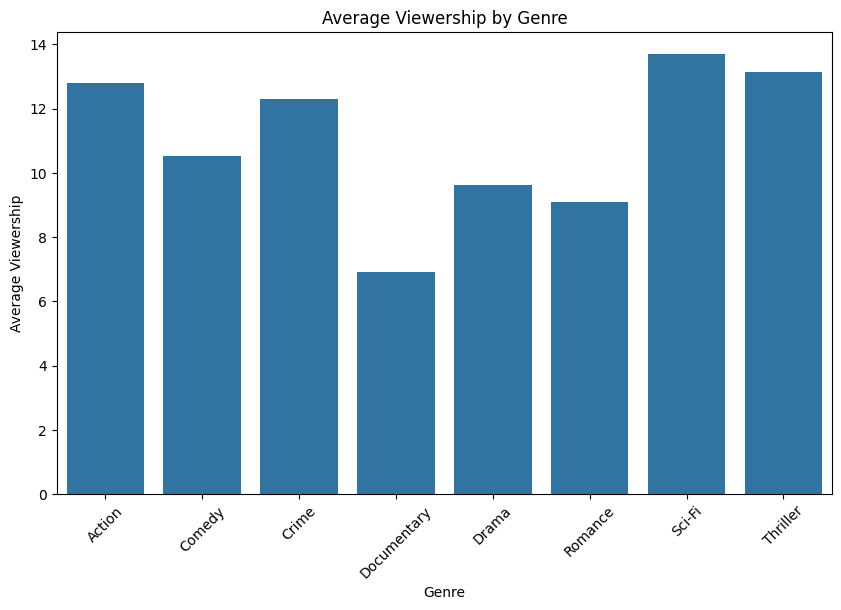

In [52]:
genre_performance = df.groupby('Genre')['Viewership'].mean().reset_index()
genre_performance.rename(columns={'Viewership': 'Average_Viewership'}, inplace=True)

plt.figure(figsize=(10,6))

sns.barplot(
    data=genre_performance,
    x="Genre",
    y="Average_Viewership"
)

plt.title("Average Viewership by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Viewership")

plt.xticks(rotation=45)

plt.show()

In [53]:
correlation = df["Rating"].corr(
    df["Viewership"]
)

print(
    "Rating vs Viewership Correlation:",
    round(correlation, 3)
)

Rating vs Viewership Correlation: 0.441


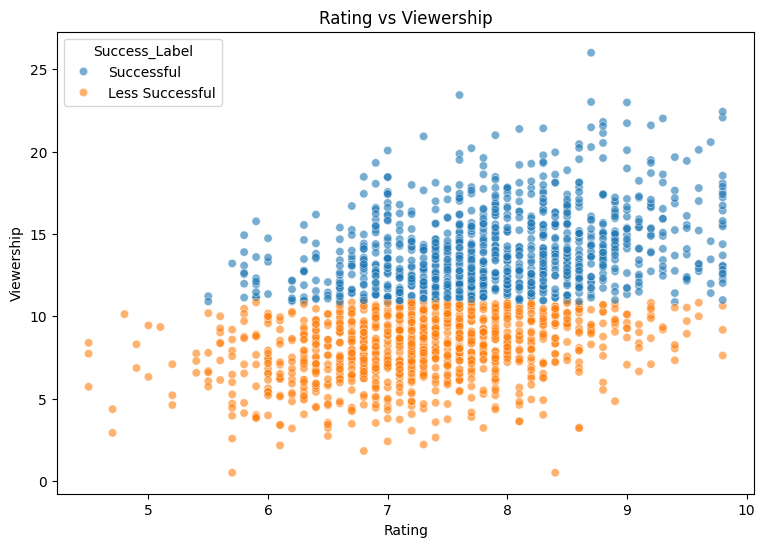

In [54]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="Rating",
    y="Viewership",
    hue="Success_Label",
    alpha=0.6
)

plt.title("Rating vs Viewership")
plt.xlabel("Rating")
plt.ylabel("Viewership")

plt.show()

In [55]:
language_performance = (
    df.groupby("Language")
      .agg(
          Average_Viewership=("Viewership", "mean"),
          Average_Rating=("Rating", "mean"),
          Average_Budget=("Budget", "mean"),
          Show_Count=("Show_ID", "count")
      )
      .sort_values(
          "Average_Viewership",
          ascending=False
      )
)

language_performance

,Average_Viewership,Average_Rating,Average_Budget,Show_Count
Language,,,,
English,12.374709,7.594188,63.832685,499
Hindi,11.769315,7.645793,62.487750,511
Telugu,10.578333,7.511957,63.079275,276
Tamil,10.295623,7.590415,64.931342,313
Kannada,9.302381,7.647090,63.701270,189
Malayalam,9.238302,7.566509,65.052642,212


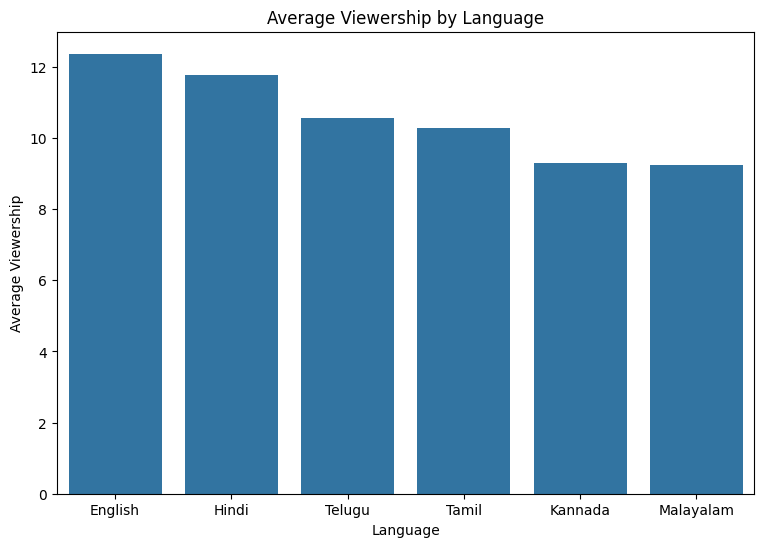

In [56]:
plt.figure(figsize=(9,6))

sns.barplot(
    data=language_performance.reset_index(),
    x="Language",
    y="Average_Viewership"
)

plt.title("Average Viewership by Language")
plt.xlabel("Language")
plt.ylabel("Average Viewership")

plt.show()

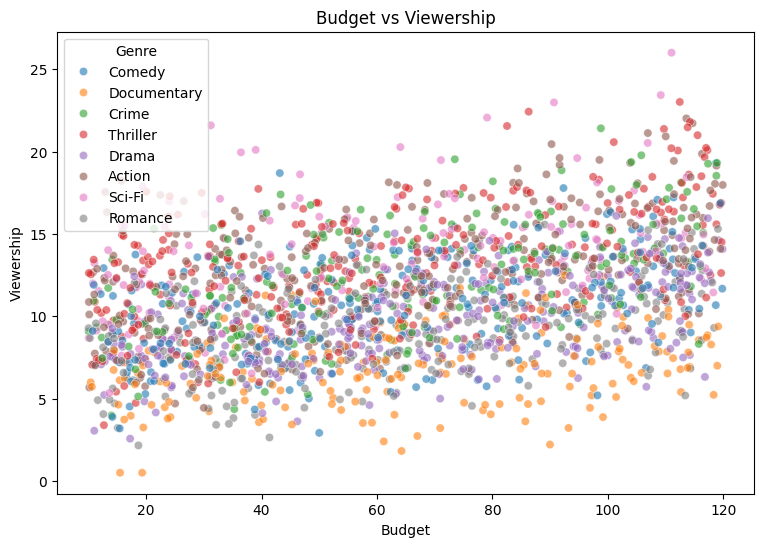

In [57]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="Budget",
    y="Viewership",
    hue="Genre",
    alpha=0.6
)

plt.title("Budget vs Viewership")
plt.xlabel("Budget")
plt.ylabel("Viewership")

plt.show()

In [58]:
runtime_analysis = (
    df.groupby(
        pd.cut(
            df["Runtime"],
            bins=[0, 30, 45, 60, 100],
            labels=[
                "20-30 min",
                "31-45 min",
                "46-60 min",
                "60+ min"
            ]
        )
    )["Viewership"]
    .mean()
)

runtime_analysis

,Viewership
Runtime,
20-30 min,10.413538
31-45 min,11.600210
46-60 min,11.340197
60+ min,10.175815


In [59]:
performance = (
    df.groupby(
        ["Genre", "Language"]
    )
    .agg(
        Average_Viewership=("Viewership", "mean"),
        Average_Rating=("Rating", "mean"),
        Average_Budget=("Budget", "mean"),
        Show_Count=("Show_ID", "count")
    )
    .sort_values(
        "Average_Viewership",
        ascending=False
    )
)

performance.head(15)

Average_Viewership  Average_Rating  Average_Budget  \
Genre    Language                                                        
Sci-Fi   English             16.292353        7.841176       60.604118   
Thriller Hindi               14.278286        7.472857       63.954143   
         English             14.272394        7.557746       56.478310   
Action   English             14.146173        7.527160       60.875062   
         Hindi               13.933333        7.726190       66.577857   
Crime    English             13.651429        7.492857       65.109821   
Sci-Fi   Hindi               13.625122        7.404878       57.408049   
Crime    Hindi               13.199057        7.771698       63.613774   
Sci-Fi   Telugu              12.881786        7.646429       63.021071   
         Tamil               12.752917        7.804167       58.538750   
Thriller Tamil               12.707174        7.634783       66.266522   
Action   Telugu              12.675435        7.663043       71.290435   
Thriller Telugu              12.597381        7.511905       60.442619   
Sci-Fi   Malayalam           12.441000        7.950000       58.667000   
         Kannada             12.213333        8.050000       70.841667   

                    Show_Count  
Genre    Language               
Sci-Fi   English            34  
Thriller Hindi              70  
         English            71  
Action   English            81  
         Hindi              84  
Crime    English            56  
Sci-Fi   Hindi              41  
Crime    Hindi              53  
Sci-Fi   Telugu             28  
         Tamil              24  
Thriller Tamil              46  
Action   Telugu             46  
Thriller Telugu             42  
Sci-Fi   Malayalam          10  
         Kannada            18

In [60]:
X = df[
    [
        "Genre",
        "Language",
        "Runtime",
        "Release_Year",
        "Budget",
        "Rating"
    ]
]

y = df["Success"]

In [61]:
categorical_features = [
    "Genre",
    "Language"
]

numeric_features = [
    "Runtime",
    "Release_Year",
    "Budget",
    "Rating"
]

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1600
Testing samples: 400


In [63]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

In [64]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    random_state=42,
    class_weight="balanced"
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", rf_model)
    ]
)

In [65]:
model.fit(
    X_train,
    y_train
)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [66]:
y_pred = model.predict(X_test)

print(y_pred[:20])

[0 0 1 0 0 1 1 0 0 0 0 1 1 1 0 0 0 1 0 1]


In [67]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Random Forest Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

Random Forest Accuracy: 83.75 %


In [68]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Less Successful",
            "Successful"
        ]
    )
)

                 precision    recall  f1-score   support

Less Successful       0.86      0.81      0.83       200
     Successful       0.82      0.87      0.84       200

       accuracy                           0.84       400
      macro avg       0.84      0.84      0.84       400
   weighted avg       0.84      0.84      0.84       400



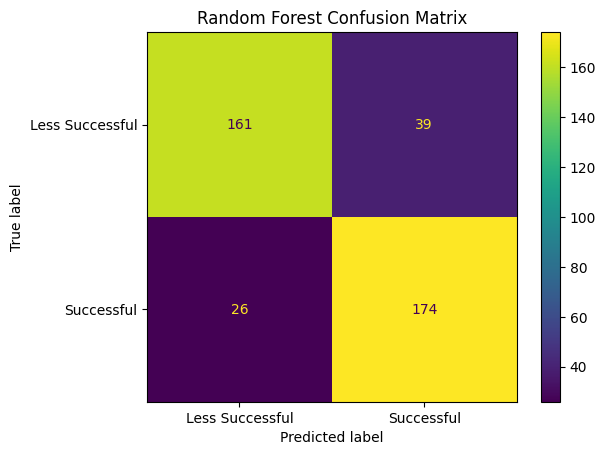

In [69]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Less Successful",
        "Successful"
    ]
)

disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

In [70]:
rf = model.named_steps["classifier"]

encoder = model.named_steps["preprocessor"]

feature_names = encoder.get_feature_names_out()

importances = rf.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
17,numeric__Rating,0.217744
16,numeric__Budget,0.200301
3,categorical__Genre_Documentary,0.119792
14,numeric__Runtime,0.075863
15,numeric__Release_Year,0.060696
5,categorical__Genre_Romance,0.056776
0,categorical__Genre_Action,0.041677
7,categorical__Genre_Thriller,0.041057
6,categorical__Genre_Sci-Fi,0.039931
4,categorical__Genre_Drama,0.030970


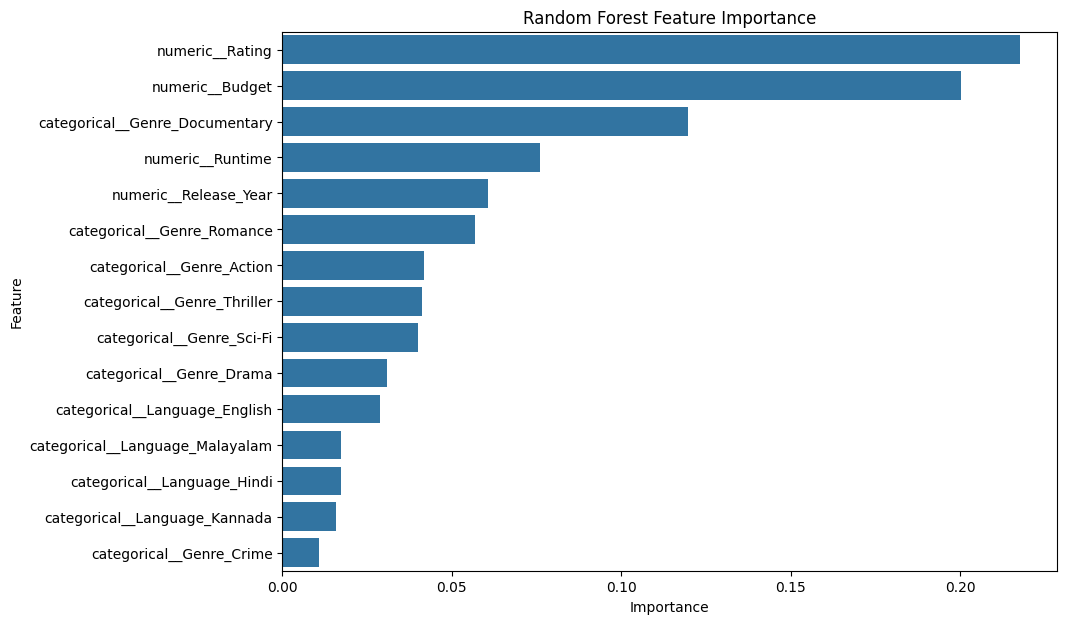

In [71]:
plt.figure(figsize=(10,7))

top_features = importance_df.head(15)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

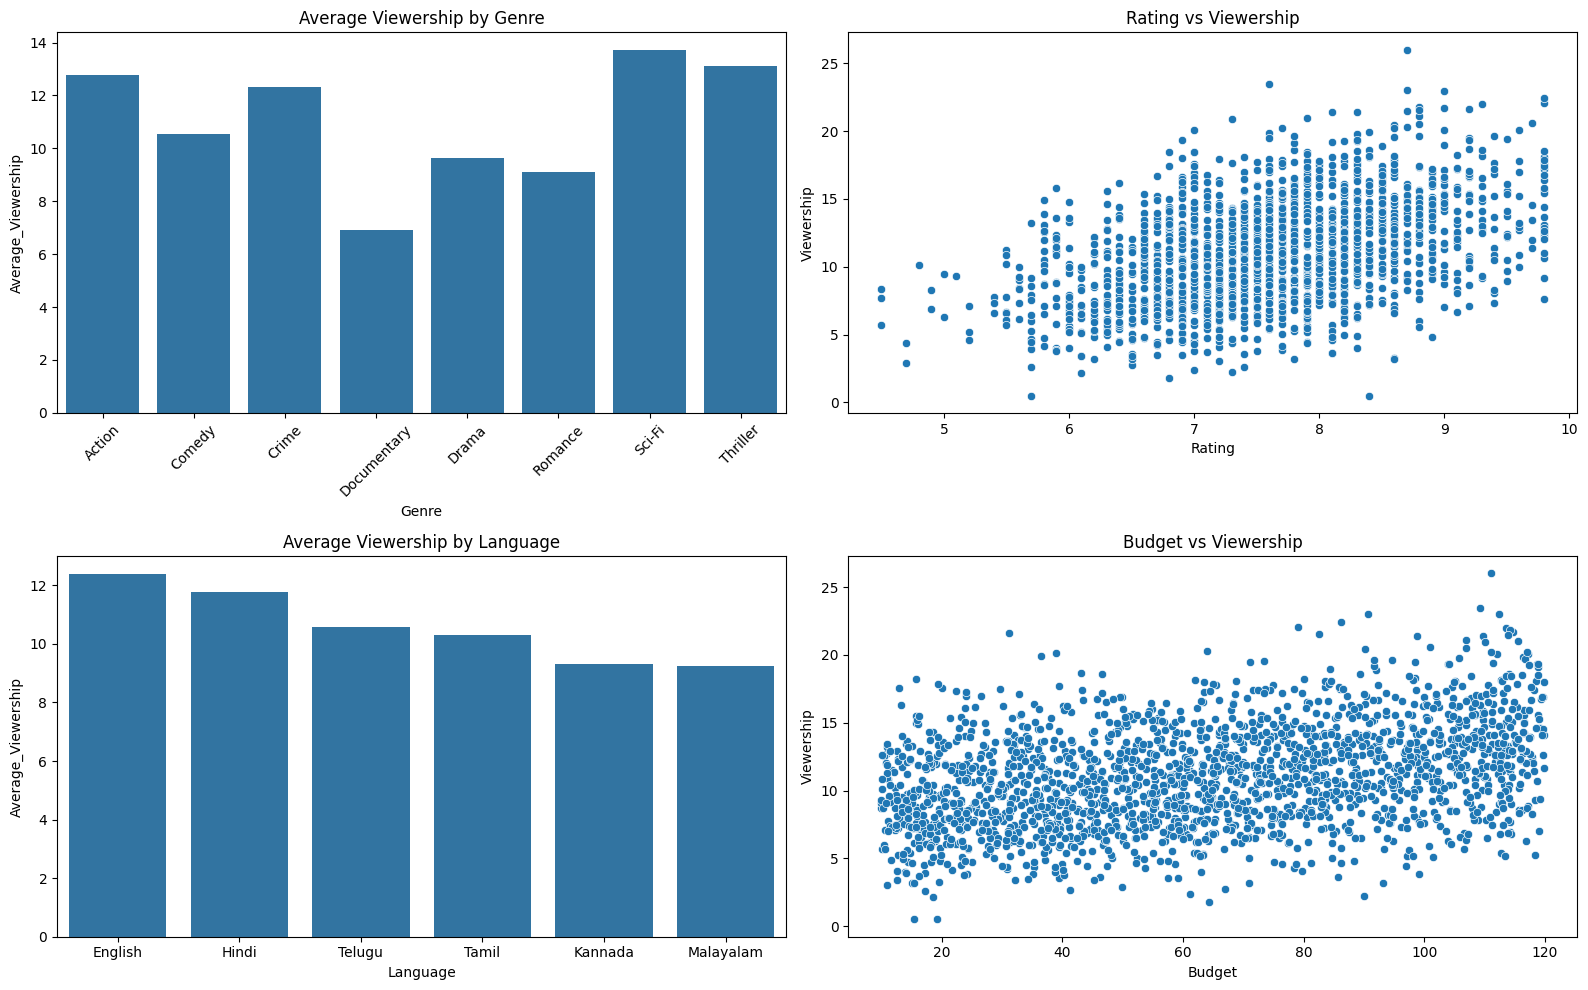

In [72]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(16,10)
)

# 1. Genre performance
sns.barplot(
    data=genre_performance.reset_index(),
    x="Genre",
    y="Average_Viewership",
    ax=axes[0,0]
)

axes[0,0].set_title(
    "Average Viewership by Genre"
)

axes[0,0].tick_params(
    axis="x",
    rotation=45
)

# 2. Rating vs Viewership
sns.scatterplot(
    data=df,
    x="Rating",
    y="Viewership",
    ax=axes[0,1]
)

axes[0,1].set_title(
    "Rating vs Viewership"
)

# 3. Language performance
sns.barplot(
    data=language_performance.reset_index(),
    x="Language",
    y="Average_Viewership",
    ax=axes[1,0]
)

axes[1,0].set_title(
    "Average Viewership by Language"
)

# 4. Budget vs Viewership
sns.scatterplot(
    data=df,
    x="Budget",
    y="Viewership",
    ax=axes[1,1]
)

axes[1,1].set_title(
    "Budget vs Viewership"
)

plt.tight_layout()
plt.show()

In [73]:
top_shows = df.sort_values(
    "Viewership",
    ascending=False
).head(10)

top_shows[
    [
        "Show_ID",
        "Genre",
        "Language",
        "Runtime",
        "Release_Year",
        "Budget",
        "Rating",
        "Viewership"
    ]
]

,Show_ID,Genre,Language,Runtime,Release_Year,Budget,Rating,Viewership
551,SHOW0552,Sci-Fi,English,41,2025,111.04,8.7,26.01
249,SHOW0250,Sci-Fi,English,50,2025,109.18,7.6,23.44
548,SHOW0549,Thriller,Hindi,53,2024,112.47,8.7,23.02
1937,SHOW1938,Sci-Fi,English,62,2024,90.67,9.0,22.99
1726,SHOW1727,Thriller,English,30,2024,86.29,9.8,22.43
574,SHOW0575,Sci-Fi,English,51,2024,79.08,9.8,22.07
299,SHOW0300,Action,Hindi,27,2024,113.61,9.3,22.02
652,SHOW0653,Thriller,Hindi,33,2025,114.24,8.8,21.81
10,SHOW0011,Action,English,41,2020,114.69,9.0,21.73
594,SHOW0595,Sci-Fi,English,38,2023,31.21,9.2,21.60


## Key Insights

1. Viewership varies considerably across different genres, indicating
   that content category is associated with audience performance.

2. Higher ratings do not always guarantee higher viewership. Some
   highly-rated shows have relatively lower audience reach.

3. Budget shows an association with viewership, but spending alone
   does not guarantee strong performance.

4. Different languages show different average viewership patterns,
   indicating differences in audience reach.

5. Runtime has an observable relationship with viewership, with some
   runtime ranges performing better than others.

6. Certain combinations of genre and language show stronger average
   performance than others.

7. Random Forest feature importance helps identify which show
   characteristics contribute most to predicting successful titles.